In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os
import pandas as pd

dataset_path = '/content/drive/MyDrive/ieee-fraud-detection.zip'
extraction_path = '/content/ieee_fraud_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

try:
    # Unzip the file
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"Successfully unzipped '{dataset_path}' to '{extraction_path}'")

    # List all CSV files in the extracted directory
    csv_files = [f for f in os.listdir(extraction_path) if f.endswith('.csv')]

    if not csv_files:
        print("No CSV files found in the extracted directory.")
    else:
        loaded_dfs = {}
        for csv_file in csv_files:
            file_path = os.path.join(extraction_path, csv_file)
            df_name = os.path.splitext(csv_file)[0] # Get filename without extension
            loaded_dfs[df_name] = pd.read_csv(file_path)
            print(f"Loaded '{csv_file}' as DataFrame '{df_name}'. Shape: {loaded_dfs[df_name].shape}")

        print("\nAll CSV files loaded successfully into the 'loaded_dfs' dictionary.")
        print("You can access them like: loaded_dfs['train_transaction'], loaded_dfs['test_identity'], etc.")

except FileNotFoundError:
    print(f"Error: The zip file at '{dataset_path}' was not found. Please check the path.")
except zipfile.BadZipFile:
    print(f"Error: '{dataset_path}' is not a valid zip file.")
except Exception as e:
    print(f"An error occurred: {e}")


Successfully unzipped '/content/drive/MyDrive/ieee-fraud-detection.zip' to '/content/ieee_fraud_data'
Loaded 'train_identity.csv' as DataFrame 'train_identity'. Shape: (144233, 41)
Loaded 'test_identity.csv' as DataFrame 'test_identity'. Shape: (141907, 41)
Loaded 'train_transaction.csv' as DataFrame 'train_transaction'. Shape: (590540, 394)
Loaded 'test_transaction.csv' as DataFrame 'test_transaction'. Shape: (506691, 393)
Loaded 'sample_submission.csv' as DataFrame 'sample_submission'. Shape: (506691, 2)

All CSV files loaded successfully into the 'loaded_dfs' dictionary.
You can access them like: loaded_dfs['train_transaction'], loaded_dfs['test_identity'], etc.


In [3]:
# shape of each dataset
for name, df in loaded_dfs.items():
    print(f"{name}: {df.shape}")

train_identity: (144233, 41)
test_identity: (141907, 41)
train_transaction: (590540, 394)
test_transaction: (506691, 393)
sample_submission: (506691, 2)


In [4]:
# Column names
for name, df in loaded_dfs.items():
    print(f"\n{name} Columns ({len(df.columns)}):")
    print(df.columns.tolist())


train_identity Columns (41):
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

test_identity Columns (41):
['TransactionID', 'id-01', 'id-02', 'id-03', 'id-04', 'id-05', 'id-06', 'id-07', 'id-08', 'id-09', 'id-10', 'id-11', 'id-12', 'id-13', 'id-14', 'id-15', 'id-16', 'id-17', 'id-18', 'id-19', 'id-20', 'id-21', 'id-22', 'id-23', 'id-24', 'id-25', 'id-26', 'id-27', 'id-28', 'id-29', 'id-30', 'id-31', 'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38', 'DeviceType', 'DeviceInfo']

train_transaction Columns (394):
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 

In [5]:
# Sample data preview
for name, df in loaded_dfs.items():
    print(f"\n{name} Preview:")
    display(df.head())


train_identity Preview:


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS



test_identity Preview:


,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW



train_transaction Preview:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



test_transaction Preview:


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



sample_submission Preview:


,TransactionID,isFraud
0,3663549,0.5
1,3663550,0.5
2,3663551,0.5
3,3663552,0.5
4,3663553,0.5


In [16]:
# Data Types & Missing values
for name, df in loaded_dfs.items():
    print(f"\n{name} Info:")
    print(df.info())


train_identity Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17  

In [17]:
# Missing Values Summary
for name, df in loaded_dfs.items():
    missing = df.isnull().sum().sum()
    total = df.size
    print(f"{name}: {missing} missing values ({(missing/total)*100:.2f}%)")

train_identity: 2104107 missing values (35.58%)
test_identity: 2105385 missing values (36.19%)
train_transaction: 95566686 missing values (41.07%)
test_transaction: 73490163 missing values (36.91%)
sample_submission: 0 missing values (0.00%)


In [18]:
# Change columns names in test_identity dataset
test_id = loaded_dfs['test_identity']
test_id.columns = test_id.columns.str.replace('-', '_')

In [19]:
# Merge Datasets
train = loaded_dfs['train_transaction'].merge(
    loaded_dfs['train_identity'],
    on='TransactionID',
    how='left'
)


In [20]:

# Analyse Target column
train['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.96501
1,0.03499


In [21]:
# Missing values
missing_percent = train.isnull().mean().sort_values(ascending=False)

missing_percent.head(20)

,0
id_24,0.991962
id_25,0.991310
id_07,0.991271
id_08,0.991271
id_21,0.991264
id_26,0.991257
id_27,0.991247
id_23,0.991247
id_22,0.991247
dist2,0.936284


In [22]:
missing_vs_fraud = train.isnull().groupby(train['isFraud']).mean().T
missing_vs_fraud['diff'] = missing_vs_fraud[1] - missing_vs_fraud[0]

missing_vs_fraud.sort_values('diff', ascending=False).head(10)

isFraud,0,1,diff
M6,0.276181,0.579345,0.303164
addr1,0.101715,0.374631,0.272916
addr2,0.101715,0.374631,0.272916
M2,0.450587,0.693075,0.242488
M3,0.450587,0.693075,0.242488
M1,0.450587,0.693075,0.242488
V4,0.464539,0.704496,0.239957
V3,0.464539,0.704496,0.239957
V8,0.464539,0.704496,0.239957
V2,0.464539,0.704496,0.239957


This gives -> Features where missingness -> fraud

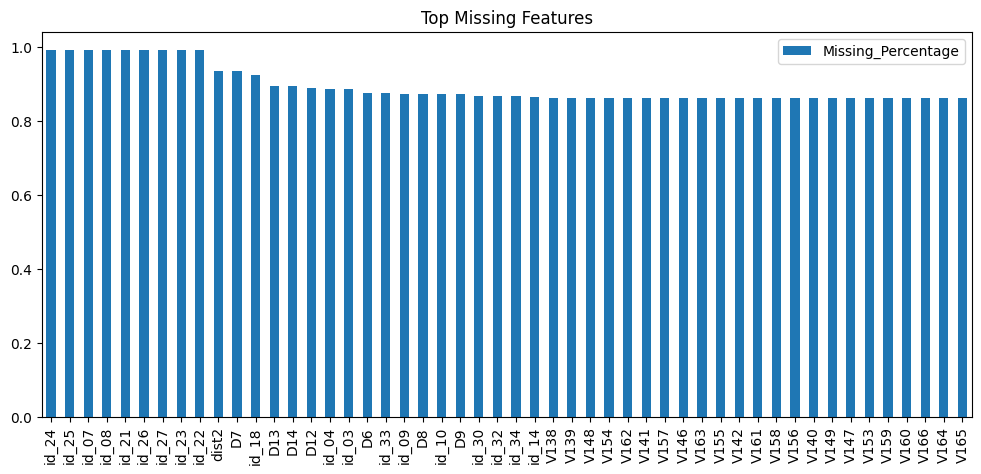

In [23]:
import matplotlib.pyplot as plt
missing_df = missing_percent.to_frame(name='Missing_Percentage')
missing_df[missing_df['Missing_Percentage'] > 0].head(50).plot(
    kind='bar', figsize=(12,5), title="Top Missing Features"
)
plt.show()

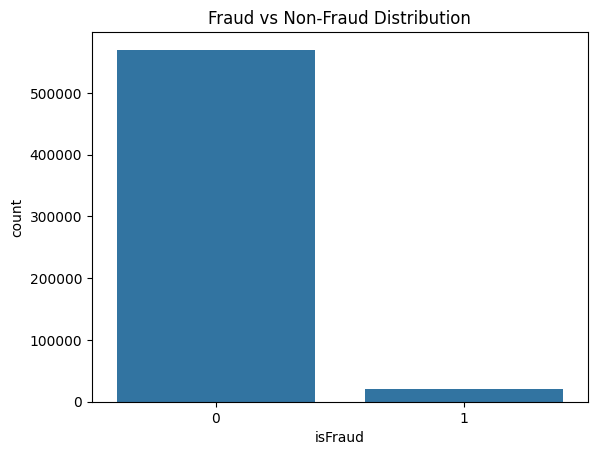

In [24]:
# Target Imbalance
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='isFraud', data=train)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

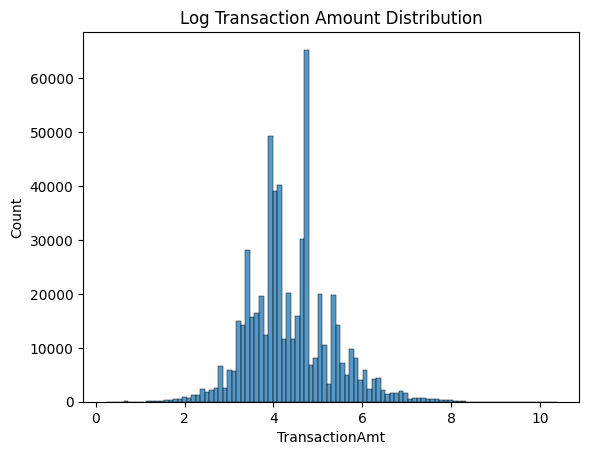

In [25]:
# Transaction AMount distribution

import numpy as np

sns.histplot(np.log1p(train['TransactionAmt']), bins=100)
plt.title("Log Transaction Amount Distribution")
plt.show()

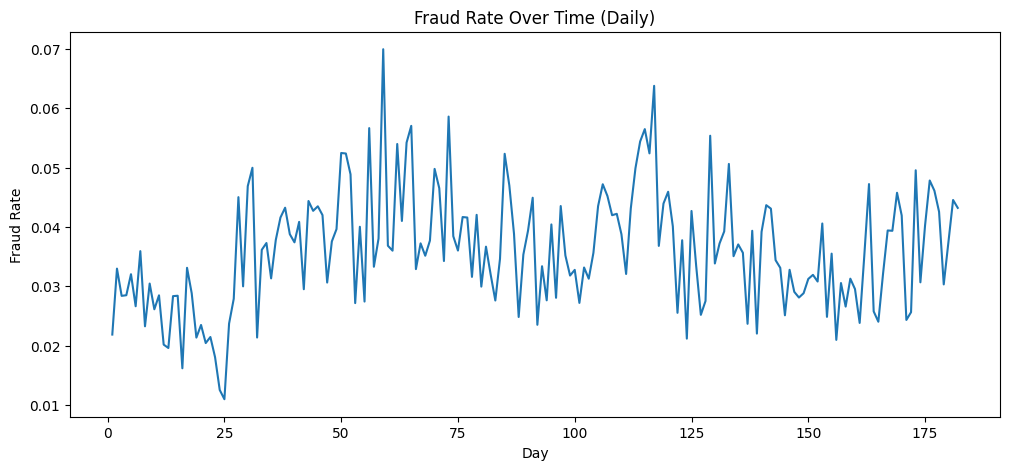

In [26]:
# Time based EDA
train['TransactionDay'] = (train['TransactionDT'] // (60*60*24)).astype(int)

fraud_time = train.groupby('TransactionDay')['isFraud'].mean()

plt.figure(figsize=(12,5))
fraud_time.plot()
plt.title("Fraud Rate Over Time (Daily)")
plt.ylabel("Fraud Rate")
plt.xlabel("Day")
plt.show()

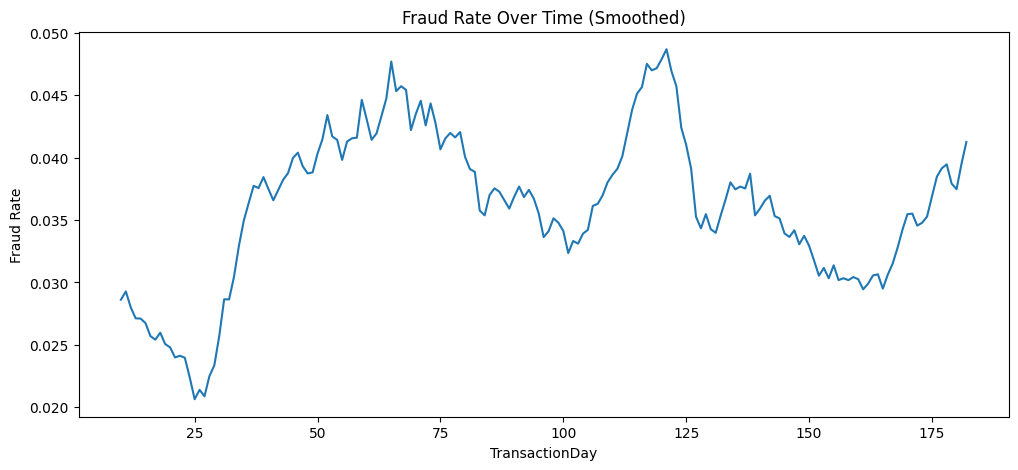

In [27]:
# Rolling Average
fraud_time_rolling = fraud_time.rolling(window=10).mean()

plt.figure(figsize=(12,5))
fraud_time_rolling.plot()
plt.title("Fraud Rate Over Time (Smoothed)")
plt.ylabel("Fraud Rate")
plt.show()

/tmp/ipykernel_1191/4083634771.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_bin = train.groupby('time_bin')['isFraud'].mean()


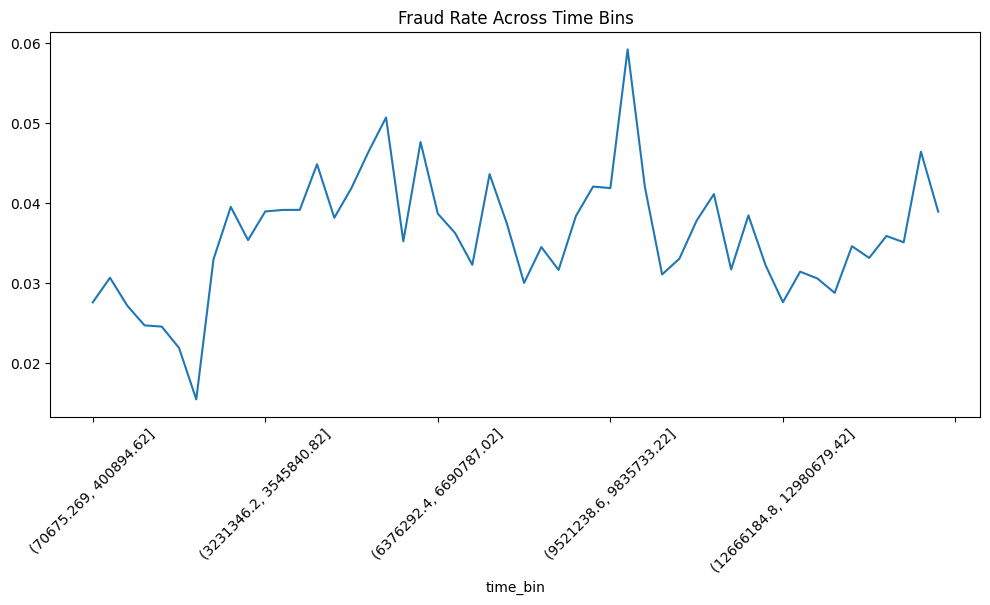

In [28]:
train['time_bin'] = pd.cut(train['TransactionDT'], bins=50)

fraud_bin = train.groupby('time_bin')['isFraud'].mean()

fraud_bin.plot(figsize=(12,5))
plt.title("Fraud Rate Across Time Bins")
plt.xticks(rotation=45)
plt.show()

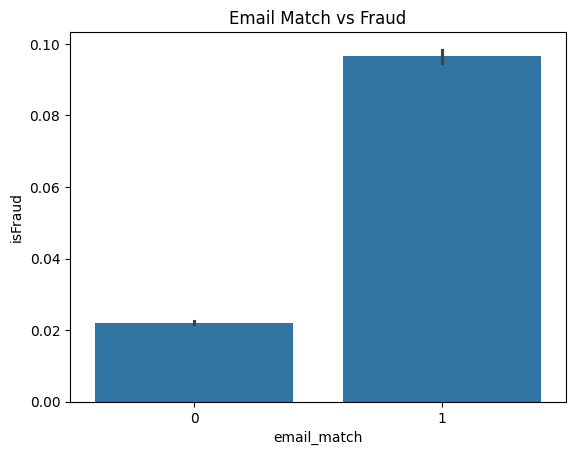

In [29]:
# Email domain mismatch
train['email_match'] = (train['P_emaildomain'] == train['R_emaildomain']).astype(int)

sns.barplot(x='email_match', y='isFraud', data=train)
plt.title("Email Match vs Fraud")
plt.show()

<Axes: xlabel='ProductCD'>

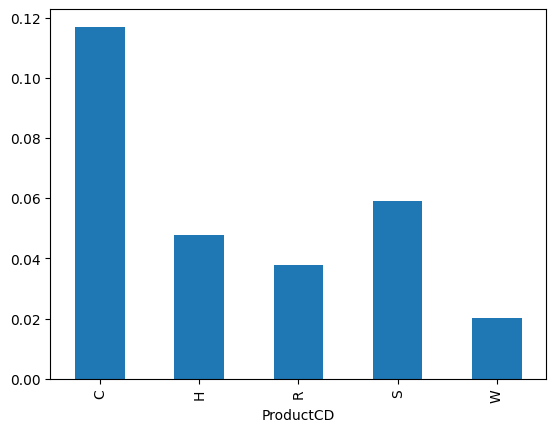

In [30]:
# Categorical features
train.groupby('ProductCD')['isFraud'].mean().plot(kind='bar')

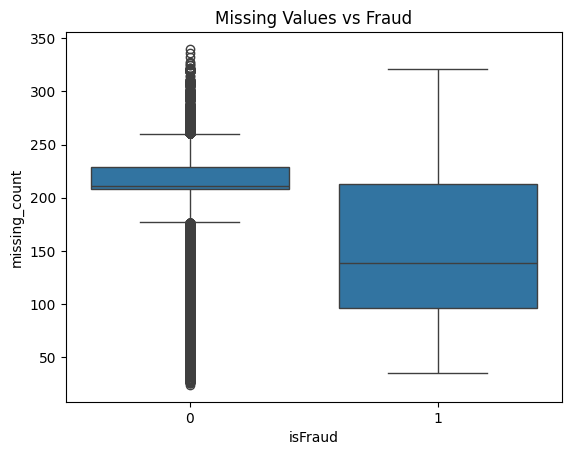

In [31]:
# Missing Values as a Feature
train['missing_count'] = train.isnull().sum(axis=1)

import seaborn as sns
sns.boxplot(x='isFraud', y='missing_count', data=train)
plt.title("Missing Values vs Fraud")
plt.show()

Created a simple model to analyze:
Confidence vs error,
Probability distribution,
Uncertainty

In [32]:
# Created a smaller dataset due to Session crashed

train_sample = train.sample(n=100000, random_state=42)

In [33]:
X = train_sample.select_dtypes(include=['number']).drop(columns=['isFraud'])
y = train_sample['isFraud']

X = X.fillna(-999)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_val)
probs = model.predict_proba(X_val)[:, 1]

In [34]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': preds,
    'Prob': probs
})

results['Model_Error'] = (results['Actual'] != results['Predicted']).astype(int)

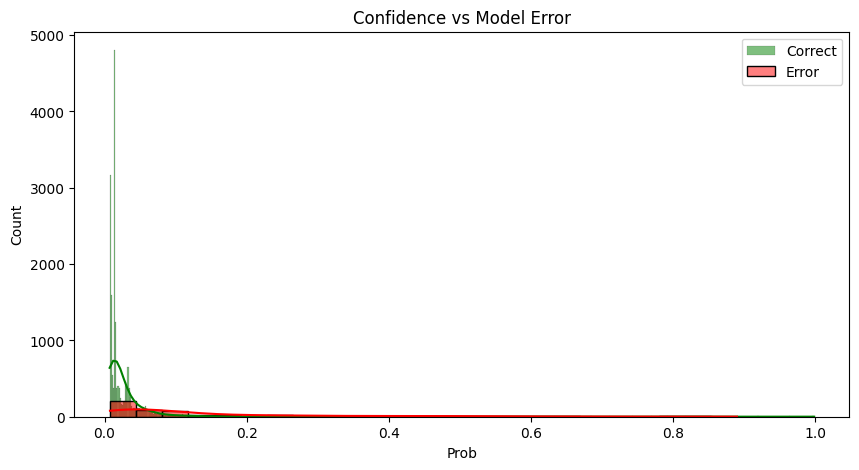

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(results[results['Model_Error']==0]['Prob'],
             label='Correct', color='green', kde=True)

sns.histplot(results[results['Model_Error']==1]['Prob'],
             label='Error', color='red', kde=True)

plt.legend()
plt.title("Confidence vs Model Error")
plt.show()

The distribution of prediction probabilities shows that model errors occur across a wide range of confidence levels rather than being concentrated only at low-confidence regions. This indicates that the model’s confidence is not a reliable indicator of correctness. In particular, the presence of errors at high probability values highlights overconfidence, while errors at mid and low probabilities suggest poor separation between correct and incorrect predictions. This motivates the need for a failure forecasting mechanism to explicitly model prediction reliability.

In [36]:
# Create confidence bias
results['confidence_bin'] = pd.cut(results['Prob'], bins=10)

/tmp/ipykernel_1191/1762140385.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = results.groupby('confidence_bin')['Model_Error'].mean()


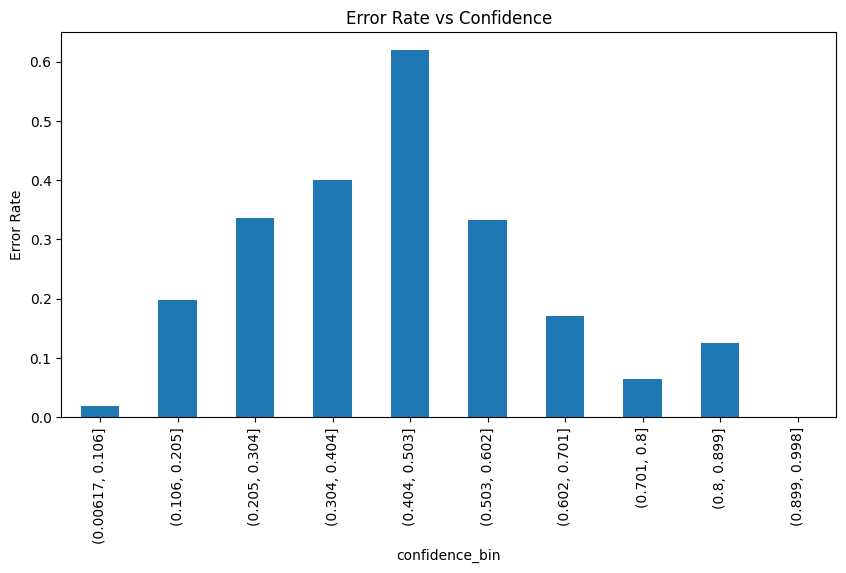

In [37]:
# Compute Error Rate per Bin
error_by_bin = results.groupby('confidence_bin')['Model_Error'].mean()

error_by_bin.plot(kind='bar', figsize=(10,5))
plt.title("Error Rate vs Confidence")
plt.ylabel("Error Rate")
plt.show()